<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/09_final_consolidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB09 — Consolidação Experimental, Figuras Finais e Calibração Probabilística

## 1. Contexto

Este notebook consolida os resultados finais da modelagem supervisionada revisada.

A entrada principal desta etapa é o arquivo de predições gerado pelo NB08:

`08_selected_model_test_predictions.parquet`

Esse arquivo contém as probabilidades previstas pelo modelo selecionado no corte temporal fixo 80/20, bem como os rótulos reais, predições binárias e metadados temporais necessários para geração das figuras finais.

A execução atual do NB08 selecionou a Regressão Logística com base no desempenho médio em validação temporal por partições progressivas (`TimeSeriesSplit`). O corte fixo permanece como análise complementar, usado principalmente para inspeção visual, geração de curvas e análise temporal das probabilidades previstas.

## 2. Objetivo

O objetivo deste notebook é:

- carregar as predições do modelo selecionado no NB08;
- gerar figuras finais para o artigo;
- calcular métricas complementares no corte fixo;
- avaliar a calibração probabilística das predições;
- produzir curva de calibração;
- produzir histograma das probabilidades previstas por classe;
- gerar a figura temporal de probabilidades previstas;
- relacionar as probabilidades previstas com episódios críticos observados;
- consolidar artefatos finais para uso no artigo e na dissertação.

## 3. Papel no Pipeline Atualizado

O NB09 tem papel editorial e analítico.

Ele não redefine a formulação do problema, não altera a base supervisionada e não seleciona novos modelos.

Sua função é consolidar visualmente e estatisticamente os resultados gerados pelo NB08, com foco em:

- matriz de confusão;
- curva ROC;
- curva Precision-Recall;
- curva de calibração;
- distribuição das probabilidades previstas;
- evolução temporal das probabilidades previstas;
- relação visual entre probabilidades e períodos críticos observados.

## 4. Interpretação das Probabilidades

As probabilidades previstas são interpretadas como escores de risco temporal associados à entrada em estado crítico dentro do horizonte supervisionado definido no NB06.

Entretanto, a interpretação dessas saídas como probabilidades calibradas depende de verificação empírica.

Por isso, esta etapa calcula:

- Brier Score;
- curva de calibração;
- erro médio de calibração por faixas de probabilidade;
- distribuição das probabilidades previstas por classe real.

Essa análise permite diferenciar duas interpretações:

1. **ordenação de risco**: capacidade de atribuir escores maiores a janelas de maior risco;
2. **calibração probabilística**: correspondência entre probabilidade prevista e frequência observada.

## 5. Relação com a Validação Temporal

A validação principal do desempenho permanece sendo o `TimeSeriesSplit` executado no NB08.

As figuras baseadas no corte fixo 80/20 devem ser tratadas como análise complementar e visual, pois esse corte apresenta mudança relevante na distribuição de classes entre treinamento e teste.

Assim, este notebook não deve ser usado para sustentar sozinho a generalização operacional do modelo.

## 6. Figuras Esperadas

Ao final deste notebook, espera-se gerar as seguintes figuras:

- `fig_01_confusion_matrix.png`;
- `fig_02_roc_curve.png`;
- `fig_03_precision_recall_curve.png`;
- `fig_04_calibration_curve.png`;
- `fig_05_prob_time.png`;
- `fig_06_probability_histogram.png`;
- `fig_07_permutation_importance_tscv.png`.

A figura `fig_05_prob_time.png` mantém o nome já utilizado no artigo para a evolução temporal das probabilidades previstas.

## 7. Saídas Esperadas

Ao final deste notebook, espera-se obter:

- figuras finais em `figures_nb09_final/`;
- `09_calibration_bins.csv`;
- `09_final_figures_summary.json`;
- `09_probability_diagnostics.csv`.

Esses artefatos serão usados para atualizar o artigo, especialmente na interpretação das probabilidades previstas e na discussão das limitações de calibração.

## 8. Observações Metodológicas

As figuras deste notebook devem ser interpretadas com cautela.

O corte fixo 80/20 é útil para visualização, mas não substitui a validação temporal principal.

A curva de calibração e o Brier Score são fundamentais para evitar afirmações excessivas sobre a qualidade probabilística do modelo.

Caso a calibração seja imperfeita, as probabilidades previstas devem ser descritas como escores de risco ou medidas relativas de ordenação, e não como probabilidades operacionais diretamente acionáveis.

[Bootstrap] Google Drive já montado.
[Bootstrap] Atualizando repositório (git pull)...
[Bootstrap] CWD = /content/drive/MyDrive/Mestrado/PPCOMP_DM
FEATURES_PATH = /content/drive/MyDrive/Mestrado/02-datasets/03-features
REPORTS_PATH = /content/drive/MyDrive/Mestrado/04-reports
[NB09_final_consolidation] Predições carregadas: shape=(1454, 9)
[NB09_final_consolidation] Arquivo: /content/drive/MyDrive/Mestrado/04-reports/08_selected_model_test_predictions.parquet

=== Head das predições ===


,bucket_id,bucket_start_us,state,transition_target,y_true,y_proba,y_pred,model,split_fraction
0,6952,2085600000000,BEFORE,0,0,0.836188,1,LogisticRegression,0.8
1,6953,2085900000000,BEFORE,0,0,0.740596,1,LogisticRegression,0.8
2,6954,2086200000000,BEFORE,1,1,0.747779,1,LogisticRegression,0.8
3,6955,2086500000000,BEFORE,1,1,0.867419,1,LogisticRegression,0.8
4,6956,2086800000000,BEFORE,1,1,0.856535,1,LogisticRegression,0.8



=== Distribuição do y_true ===


,count
y_true,
0,516
1,938



=== state × y_true ===


y_true,0,1
state,,
BEFORE,313,938
NORMAL,203,0



=== Métricas complementares no corte fixo ===


,accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,tn,fp,fn,tp,support,positives,positive_rate,threshold
0,0.722146,0.717427,0.939232,0.813481,0.765237,0.832725,0.193989,169,347,57,881,1454,938,0.645117,0.5


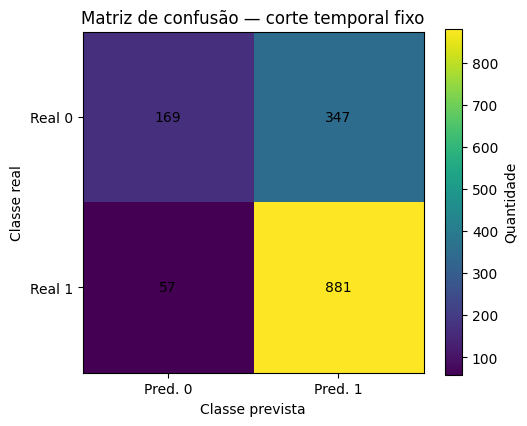

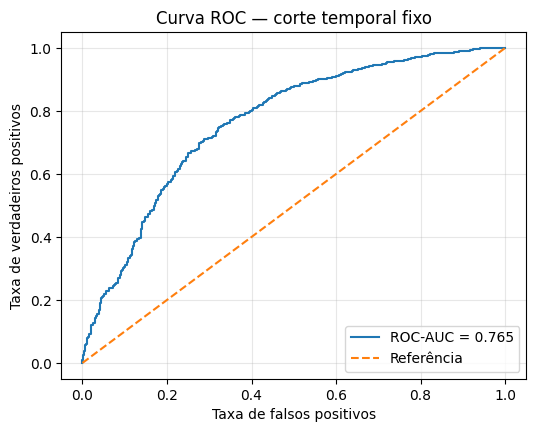

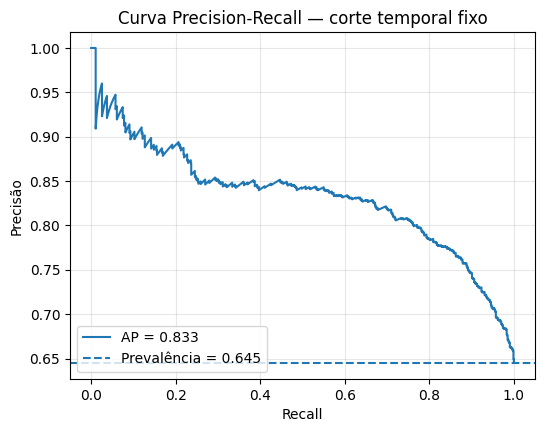


=== Curva de calibração — quantis ===


,bin,mean_predicted_probability,observed_positive_fraction,absolute_gap
0,1,0.295418,0.212329,0.083089
1,2,0.489682,0.365517,0.124165
2,3,0.628185,0.441379,0.186806
3,4,0.733887,0.595890,0.137997
4,5,0.812781,0.696552,0.116229
5,6,0.872059,0.772414,0.099646
6,7,0.910032,0.835616,0.074415
7,8,0.938587,0.834483,0.104104
8,9,0.961755,0.800000,0.161755
9,10,0.984433,0.897260,0.087173



=== Diagnóstico de calibração — bins uniformes ===


,bin,bin_left,bin_right,count,mean_predicted_probability,observed_positive_fraction,absolute_gap,weighted_gap
0,1,0.0,0.1,1,0.083776,0.000000,0.083776,0.000058
1,2,0.1,0.2,21,0.164023,0.047619,0.116404,0.001681
2,3,0.2,0.3,50,0.252988,0.220000,0.032988,0.001134
3,4,0.3,0.4,60,0.353606,0.250000,0.103606,0.004275
4,5,0.4,0.5,94,0.447275,0.319149,0.128126,0.008283
5,6,0.5,0.6,102,0.551037,0.392157,0.158880,0.011146
6,7,0.6,0.7,122,0.649970,0.508197,0.141773,0.011896
7,8,0.7,0.8,174,0.750161,0.614943,0.135218,0.016182
8,9,0.8,0.9,277,0.856247,0.743682,0.112564,0.021445
9,10,0.9,1.0,553,0.951472,0.842676,0.108796,0.041378



Brier Score: 0.193989
ECE aproximado: 0.117478


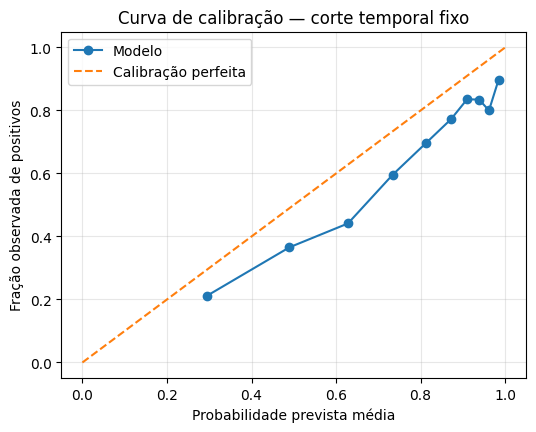

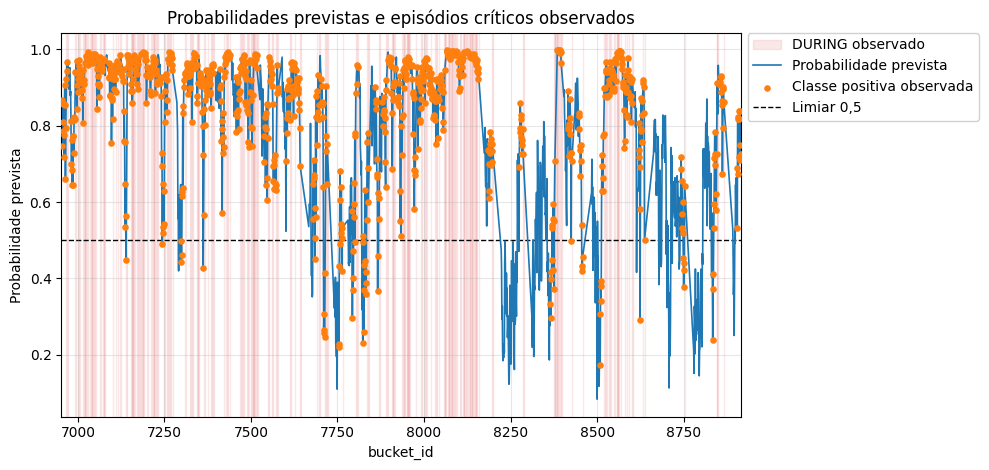

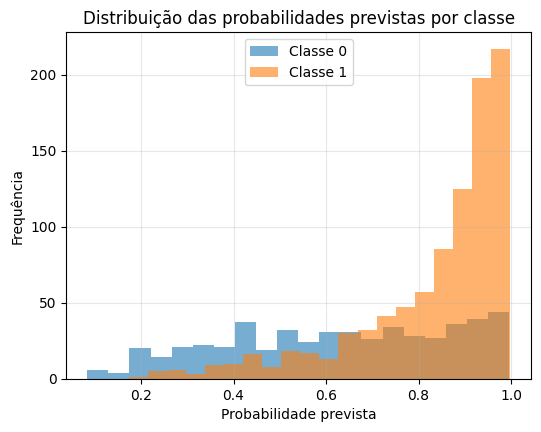

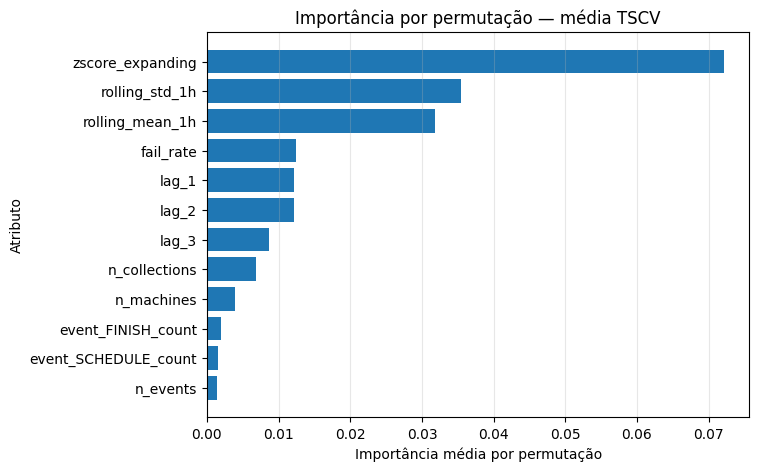


=== Diagnósticos das probabilidades por classe ===


,class,count,mean_proba,std_proba,min_proba,p25_proba,median_proba,p75_proba,max_proba
0,0,516,0.626288,0.240293,0.083776,0.437415,0.638393,0.833868,0.995925
1,1,938,0.837578,0.163944,0.173583,0.774906,0.898533,0.952960,0.997849


[NB09_final_consolidation] Resumo final salvo: /content/drive/MyDrive/Mestrado/04-reports/09_final_figures_summary.json

=== RESUMO FINAL — NB09 ===
Predições: (1454, 9)
Modelo selecionado: LogisticRegression
Bucket range: 6952..8915

Métricas no corte fixo:


,accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,tn,fp,fn,tp,support,positives,positive_rate,threshold
0,0.722146,0.717427,0.939232,0.813481,0.765237,0.832725,0.193989,169,347,57,881,1454,938,0.645117,0.5



Brier Score: 0.193989
ECE aproximado: 0.117478

Diagnóstico das probabilidades por classe:


,class,count,mean_proba,std_proba,min_proba,p25_proba,median_proba,p75_proba,max_proba
0,0,516,0.626288,0.240293,0.083776,0.437415,0.638393,0.833868,0.995925
1,1,938,0.837578,0.163944,0.173583,0.774906,0.898533,0.952960,0.997849



Figuras geradas:
- fig_01_confusion_matrix: /content/drive/MyDrive/Mestrado/PPCOMP_DM/figures_nb09_final/fig_01_confusion_matrix.png
- fig_02_roc_curve: /content/drive/MyDrive/Mestrado/PPCOMP_DM/figures_nb09_final/fig_02_roc_curve.png
- fig_03_precision_recall_curve: /content/drive/MyDrive/Mestrado/PPCOMP_DM/figures_nb09_final/fig_03_precision_recall_curve.png
- fig_04_calibration_curve: /content/drive/MyDrive/Mestrado/PPCOMP_DM/figures_nb09_final/fig_04_calibration_curve.png
- fig_05_prob_time: /content/drive/MyDrive/Mestrado/PPCOMP_DM/figures_nb09_final/fig_05_prob_time.png
- fig_06_probability_histogram: /content/drive/MyDrive/Mestrado/PPCOMP_DM/figures_nb09_final/fig_06_probability_histogram.png
- fig_07_permutation_importance_tscv: /content/drive/MyDrive/Mestrado/PPCOMP_DM/figures_nb09_final/fig_07_permutation_importance_tscv.png


In [3]:
# ============================================================
# NB09 — Consolidação Experimental, Figuras Finais e Calibração
# Versão revisada após NB08 com primary_K24_H12
# ============================================================

from pathlib import Path
import os
import sys
import subprocess
import importlib
import random
import json
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# 0) BOOTSTRAP
# -----------------------------

if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("[Bootstrap] Google Drive já montado.")

REPO_DIR = Path("/content/drive/MyDrive/Mestrado/PPCOMP_DM")
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if not REPO_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    print(f"[Bootstrap] Clonando repositório em: {REPO_DIR}")
    subprocess.run(["git", "clone", GITHUB_REPO, str(REPO_DIR)], check=True)
else:
    try:
        print("[Bootstrap] Atualizando repositório (git pull)...")
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível atualizar via git pull:", e)

os.chdir(str(REPO_DIR))
print("[Bootstrap] CWD =", os.getcwd())

repo_str = str(REPO_DIR)
if repo_str not in sys.path:
    sys.path.insert(0, repo_str)

importlib.invalidate_caches()

from src.paths import FEATURES_PATH, REPORTS_PATH, ensure_dirs

ensure_dirs()

print("FEATURES_PATH =", FEATURES_PATH)
print("REPORTS_PATH =", REPORTS_PATH)

def log(msg: str) -> None:
    print(f"[NB09_final_consolidation] {msg}")


# -----------------------------
# 1) PARÂMETROS E ARQUIVOS
# -----------------------------

PROBA_THRESHOLD = 0.50
WINDOW_MINUTES = 5

PREDICTIONS_FILE = REPORTS_PATH / "08_selected_model_test_predictions.parquet"
NB08_SUMMARY_FILE = REPORTS_PATH / "08_supervised_modeling_summary.json"
TSCV_SUMMARY_FILE = REPORTS_PATH / "08_tscv_summary.csv"
FIXED_METRICS_FILE = REPORTS_PATH / "08_fixed_split_metrics.csv"
PERM_TSCV_FILE = REPORTS_PATH / "08_permutation_importance_tscv.csv"
PERM_FIXED_FILE = REPORTS_PATH / "08_permutation_importance_fixed.csv"

LABELED_FILE = FEATURES_PATH / "window_5min_labeled.parquet"
EPISODES_FILE = FEATURES_PATH / "episodes_detected.parquet"

FIG_DIR = REPO_DIR / "figures_nb09_final"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Cópia opcional em reports para rastreabilidade.
REPORT_FIG_DIR = REPORTS_PATH / "figures_nb09_final"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

CALIBRATION_BINS_FILE = REPORTS_PATH / "09_calibration_bins.csv"
PROBABILITY_DIAGNOSTICS_FILE = REPORTS_PATH / "09_probability_diagnostics.csv"
SUMMARY_FILE = REPORTS_PATH / "09_final_figures_summary.json"


# -----------------------------
# 2) LEITURA DOS ARTEFATOS
# -----------------------------

assert PREDICTIONS_FILE.exists(), f"Arquivo não encontrado: {PREDICTIONS_FILE}"

df_pred = pd.read_parquet(PREDICTIONS_FILE)

required_pred_cols = {"y_true", "y_proba", "y_pred"}
missing_pred = required_pred_cols - set(df_pred.columns)
assert not missing_pred, f"Colunas ausentes nas predições: {missing_pred}"

df_pred = df_pred.copy()

if "bucket_id" in df_pred.columns:
    df_pred = df_pred.sort_values("bucket_id").reset_index(drop=True)
else:
    df_pred = df_pred.reset_index(drop=True)
    df_pred["bucket_id"] = df_pred.index

df_pred["y_true"] = df_pred["y_true"].astype(int)
df_pred["y_pred"] = df_pred["y_pred"].astype(int)
df_pred["y_proba"] = df_pred["y_proba"].astype(float)

log(f"Predições carregadas: shape={df_pred.shape}")
log(f"Arquivo: {PREDICTIONS_FILE}")

if NB08_SUMMARY_FILE.exists():
    nb08_summary = json.loads(NB08_SUMMARY_FILE.read_text(encoding="utf-8"))
else:
    nb08_summary = {}

if TSCV_SUMMARY_FILE.exists():
    df_tscv_summary = pd.read_csv(TSCV_SUMMARY_FILE)
else:
    df_tscv_summary = pd.DataFrame()

if FIXED_METRICS_FILE.exists():
    df_fixed_metrics = pd.read_csv(FIXED_METRICS_FILE)
else:
    df_fixed_metrics = pd.DataFrame()

if PERM_TSCV_FILE.exists():
    df_perm_tscv = pd.read_csv(PERM_TSCV_FILE)
else:
    df_perm_tscv = pd.DataFrame()

if PERM_FIXED_FILE.exists():
    df_perm_fixed = pd.read_csv(PERM_FIXED_FILE)
else:
    df_perm_fixed = pd.DataFrame()

if LABELED_FILE.exists():
    df_labeled = pd.read_parquet(LABELED_FILE).sort_values("bucket_id").reset_index(drop=True)
else:
    df_labeled = pd.DataFrame()

if EPISODES_FILE.exists():
    df_episodes = pd.read_parquet(EPISODES_FILE).sort_values("start_bucket").reset_index(drop=True)
else:
    df_episodes = pd.DataFrame()


print("\n=== Head das predições ===")
display(df_pred.head())

print("\n=== Distribuição do y_true ===")
display(df_pred["y_true"].value_counts().sort_index().to_frame("count"))

if "state" in df_pred.columns:
    print("\n=== state × y_true ===")
    display(pd.crosstab(df_pred["state"], df_pred["y_true"]))


# -----------------------------
# 3) MÉTRICAS COMPLEMENTARES DO CORTE FIXO
# -----------------------------

y_true = df_pred["y_true"].to_numpy()
y_proba = df_pred["y_proba"].to_numpy()
y_pred = (y_proba >= PROBA_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "precision": float(precision_score(y_true, y_pred, zero_division=0)),
    "recall": float(recall_score(y_true, y_pred, zero_division=0)),
    "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_true, y_proba)) if len(np.unique(y_true)) > 1 else np.nan,
    "average_precision": float(average_precision_score(y_true, y_proba)) if len(np.unique(y_true)) > 1 else np.nan,
    "brier_score": float(brier_score_loss(y_true, y_proba)),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "support": int(len(y_true)),
    "positives": int(y_true.sum()),
    "positive_rate": float(y_true.mean()),
    "threshold": float(PROBA_THRESHOLD),
}

print("\n=== Métricas complementares no corte fixo ===")
display(pd.DataFrame([metrics]))


# -----------------------------
# 4) FUNÇÕES DE PLOTAGEM E SALVAMENTO
# -----------------------------

def save_current_figure(filename: str) -> dict:
    out_repo = FIG_DIR / filename
    out_reports = REPORT_FIG_DIR / filename

    plt.savefig(out_repo, dpi=300, bbox_inches="tight")
    plt.savefig(out_reports, dpi=300, bbox_inches="tight")

    return {
        "repo_path": str(out_repo),
        "reports_path": str(out_reports),
    }


def format_float(x, digits=3):
    if pd.isna(x):
        return "NA"
    return f"{x:.{digits}f}"


figures = {}


# -----------------------------
# 5) FIGURA 1 — MATRIZ DE CONFUSÃO
# -----------------------------

cm = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm)
plt.title("Matriz de confusão — corte temporal fixo")
plt.xticks([0, 1], ["Pred. 0", "Pred. 1"])
plt.yticks([0, 1], ["Real 0", "Real 1"])
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar(label="Quantidade")
figures["fig_01_confusion_matrix"] = save_current_figure("fig_01_confusion_matrix.png")
plt.show()


# -----------------------------
# 6) FIGURA 2 — CURVA ROC
# -----------------------------

fpr, tpr, roc_thresholds = roc_curve(y_true, y_proba)
roc_auc_value = metrics["roc_auc"]

plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {format_float(roc_auc_value)}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Referência")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curva ROC — corte temporal fixo")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
figures["fig_02_roc_curve"] = save_current_figure("fig_02_roc_curve.png")
plt.show()


# -----------------------------
# 7) FIGURA 3 — CURVA PRECISION-RECALL
# -----------------------------

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_proba)
ap_value = metrics["average_precision"]
baseline = float(np.mean(y_true))

plt.figure(figsize=(6, 4.5))
plt.plot(recall, precision, label=f"AP = {format_float(ap_value)}")
plt.axhline(baseline, linestyle="--", label=f"Prevalência = {format_float(baseline)}")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva Precision-Recall — corte temporal fixo")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
figures["fig_03_precision_recall_curve"] = save_current_figure("fig_03_precision_recall_curve.png")
plt.show()


# -----------------------------
# 8) CALIBRAÇÃO PROBABILÍSTICA
# -----------------------------

# Curva de calibração por quantis evita bins vazios em distribuições concentradas.
prob_true, prob_pred = calibration_curve(
    y_true,
    y_proba,
    n_bins=10,
    strategy="quantile",
)

calibration_curve_df = pd.DataFrame({
    "bin": np.arange(1, len(prob_true) + 1),
    "mean_predicted_probability": prob_pred,
    "observed_positive_fraction": prob_true,
    "absolute_gap": np.abs(prob_true - prob_pred),
})

# Tabela adicional por bins uniformes para diagnóstico.
bin_edges = np.linspace(0.0, 1.0, 11)
bin_ids = np.digitize(y_proba, bin_edges, right=True)
bin_ids = np.clip(bin_ids, 1, 10)

rows = []

for b in range(1, 11):
    mask = bin_ids == b
    n = int(mask.sum())

    if n == 0:
        rows.append({
            "bin": b,
            "bin_left": float(bin_edges[b - 1]),
            "bin_right": float(bin_edges[b]),
            "count": 0,
            "mean_predicted_probability": np.nan,
            "observed_positive_fraction": np.nan,
            "absolute_gap": np.nan,
            "weighted_gap": 0.0,
        })
        continue

    mean_pred = float(y_proba[mask].mean())
    obs_frac = float(y_true[mask].mean())
    abs_gap = float(abs(obs_frac - mean_pred))

    rows.append({
        "bin": b,
        "bin_left": float(bin_edges[b - 1]),
        "bin_right": float(bin_edges[b]),
        "count": n,
        "mean_predicted_probability": mean_pred,
        "observed_positive_fraction": obs_frac,
        "absolute_gap": abs_gap,
        "weighted_gap": float(abs_gap * n / len(y_true)),
    })

calibration_bins_df = pd.DataFrame(rows)

ece = float(calibration_bins_df["weighted_gap"].sum())

calibration_bins_df.to_csv(CALIBRATION_BINS_FILE, index=False)

print("\n=== Curva de calibração — quantis ===")
display(calibration_curve_df)

print("\n=== Diagnóstico de calibração — bins uniformes ===")
display(calibration_bins_df)

print(f"\nBrier Score: {metrics['brier_score']:.6f}")
print(f"ECE aproximado: {ece:.6f}")


# -----------------------------
# 9) FIGURA 4 — CURVA DE CALIBRAÇÃO
# -----------------------------

plt.figure(figsize=(6, 4.5))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo")
plt.plot([0, 1], [0, 1], linestyle="--", label="Calibração perfeita")
plt.xlabel("Probabilidade prevista média")
plt.ylabel("Fração observada de positivos")
plt.title("Curva de calibração — corte temporal fixo")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
figures["fig_04_calibration_curve"] = save_current_figure("fig_04_calibration_curve.png")
plt.show()


# -----------------------------
# 10) FIGURA 5 — PROBABILIDADES AO LONGO DO TEMPO
# -----------------------------

df_time = df_pred.copy().sort_values("bucket_id").reset_index(drop=True)

x = df_time["bucket_id"].to_numpy()
p = df_time["y_proba"].to_numpy()

plt.figure(figsize=(10, 4.8))

# Marca episódios DURING observados a partir da base rotulada, se disponível.
during_spans = []

if not df_labeled.empty and {"bucket_id", "state"}.issubset(df_labeled.columns):
    test_min_bucket = int(df_time["bucket_id"].min())
    test_max_bucket = int(df_time["bucket_id"].max())

    during_df = df_labeled.loc[
        (df_labeled["bucket_id"] >= test_min_bucket) &
        (df_labeled["bucket_id"] <= test_max_bucket) &
        (df_labeled["state"] == "DURING"),
        ["bucket_id", "state"]
    ].copy()

    if len(during_df) > 0:
        during_buckets = during_df["bucket_id"].to_numpy()

        start = during_buckets[0]
        prev = during_buckets[0]

        for b in during_buckets[1:]:
            if b == prev + 1:
                prev = b
            else:
                during_spans.append((int(start), int(prev)))
                start = b
                prev = b

        during_spans.append((int(start), int(prev)))

        for i, (s, e) in enumerate(during_spans):
            plt.axvspan(
                s - 0.5,
                e + 0.5,
                color="tab:red",
                alpha=0.10,
                zorder=0,
                label="DURING observado" if i == 0 else None,
            )

plt.plot(
    x,
    p,
    color="tab:blue",
    linewidth=1.2,
    label="Probabilidade prevista",
    zorder=2,
)

plt.scatter(
    df_time.loc[df_time["y_true"] == 1, "bucket_id"],
    df_time.loc[df_time["y_true"] == 1, "y_proba"],
    color="tab:orange",
    s=14,
    label="Classe positiva observada",
    zorder=3,
)

plt.axhline(
    PROBA_THRESHOLD,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label="Limiar 0,5",
    zorder=1,
)

plt.xlabel("bucket_id")
plt.ylabel("Probabilidade prevista")
plt.title("Probabilidades previstas e episódios críticos observados")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0.0,
    framealpha=0.9
)

plt.grid(True, alpha=0.3)
plt.xlim(df_time["bucket_id"].min(), df_time["bucket_id"].max())
plt.tight_layout()

figures["fig_05_prob_time"] = save_current_figure("fig_05_prob_time.png")
plt.show()


# -----------------------------
# 11) FIGURA 6 — HISTOGRAMA DAS PROBABILIDADES POR CLASSE
# -----------------------------

plt.figure(figsize=(6, 4.5))
plt.hist(
    df_pred.loc[df_pred["y_true"] == 0, "y_proba"],
    bins=20,
    alpha=0.6,
    label="Classe 0",
)
plt.hist(
    df_pred.loc[df_pred["y_true"] == 1, "y_proba"],
    bins=20,
    alpha=0.6,
    label="Classe 1",
)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência")
plt.title("Distribuição das probabilidades previstas por classe")
plt.legend(loc="upper center")
plt.grid(True, alpha=0.3)
figures["fig_06_probability_histogram"] = save_current_figure("fig_06_probability_histogram.png")
plt.show()


# -----------------------------
# 12) FIGURA 7 — IMPORTÂNCIA POR PERMUTAÇÃO TSCV
# -----------------------------

if not df_perm_tscv.empty and "importance_mean_tscv" in df_perm_tscv.columns:
    df_imp = df_perm_tscv.sort_values("importance_mean_tscv", ascending=False).head(12).copy()
    df_imp = df_imp.sort_values("importance_mean_tscv", ascending=True)

    plt.figure(figsize=(7, 5))
    plt.barh(df_imp["feature"], df_imp["importance_mean_tscv"])
    plt.xlabel("Importância média por permutação")
    plt.ylabel("Atributo")
    plt.title("Importância por permutação — média TSCV")
    plt.grid(True, axis="x", alpha=0.3)
    figures["fig_07_permutation_importance_tscv"] = save_current_figure("fig_07_permutation_importance_tscv.png")
    plt.show()
else:
    log("Arquivo de importância TSCV indisponível ou sem coluna importance_mean_tscv.")


# -----------------------------
# 13) DIAGNÓSTICOS DE PROBABILIDADE
# -----------------------------

probability_diagnostics = []

for class_value in [0, 1]:
    vals = df_pred.loc[df_pred["y_true"] == class_value, "y_proba"]

    if len(vals) == 0:
        continue

    probability_diagnostics.append({
        "class": int(class_value),
        "count": int(len(vals)),
        "mean_proba": float(vals.mean()),
        "std_proba": float(vals.std(ddof=1)) if len(vals) > 1 else 0.0,
        "min_proba": float(vals.min()),
        "p25_proba": float(vals.quantile(0.25)),
        "median_proba": float(vals.median()),
        "p75_proba": float(vals.quantile(0.75)),
        "max_proba": float(vals.max()),
    })

probability_diagnostics_df = pd.DataFrame(probability_diagnostics)
probability_diagnostics_df.to_csv(PROBABILITY_DIAGNOSTICS_FILE, index=False)

print("\n=== Diagnósticos das probabilidades por classe ===")
display(probability_diagnostics_df)


# -----------------------------
# 14) RESUMO JSON
# -----------------------------

selected_model = None

if "model" in df_pred.columns and df_pred["model"].notna().any():
    selected_model = str(df_pred["model"].dropna().iloc[0])
else:
    selected_model = nb08_summary.get("selected_model", None)

summary = {
    "notebook": "NB09",
    "purpose": "final_figures_probability_diagnostics_and_calibration",
    "input_predictions_file": str(PREDICTIONS_FILE),
    "selected_model": selected_model,
    "threshold": float(PROBA_THRESHOLD),
    "prediction_rows": int(len(df_pred)),
    "prediction_bucket_min": int(df_pred["bucket_id"].min()) if "bucket_id" in df_pred.columns else None,
    "prediction_bucket_max": int(df_pred["bucket_id"].max()) if "bucket_id" in df_pred.columns else None,
    "metrics_fixed_split": metrics,
    "calibration": {
        "brier_score": float(metrics["brier_score"]),
        "ece_uniform_bins": float(ece),
        "n_calibration_bins_quantile": int(len(calibration_curve_df)),
        "n_uniform_bins": int(len(calibration_bins_df)),
    },
    "during_spans_in_prediction_range": during_spans,
    "probability_diagnostics": probability_diagnostics_df.to_dict("records"),
    "figures": figures,
    "outputs": {
        "figures_repo_dir": str(FIG_DIR),
        "figures_reports_dir": str(REPORT_FIG_DIR),
        "calibration_bins_file": str(CALIBRATION_BINS_FILE),
        "probability_diagnostics_file": str(PROBABILITY_DIAGNOSTICS_FILE),
        "summary_file": str(SUMMARY_FILE),
    },
    "interpretation_note": (
        "Fixed-split figures are used for visualization and editorial consolidation. "
        "TimeSeriesSplit remains the primary validation protocol. Predicted probabilities "
        "should be interpreted as risk scores unless calibration diagnostics support "
        "strong probabilistic interpretation."
    ),
}

SUMMARY_FILE.write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

log(f"Resumo final salvo: {SUMMARY_FILE}")


# -----------------------------
# 15) RESUMO FINAL NA TELA
# -----------------------------

print("\n=== RESUMO FINAL — NB09 ===")
print(f"Predições: {df_pred.shape}")
print(f"Modelo selecionado: {selected_model}")
print(f"Bucket range: {summary['prediction_bucket_min']}..{summary['prediction_bucket_max']}")
print()
print("Métricas no corte fixo:")
display(pd.DataFrame([metrics]))
print()
print(f"Brier Score: {metrics['brier_score']:.6f}")
print(f"ECE aproximado: {ece:.6f}")
print()
print("Diagnóstico das probabilidades por classe:")
display(probability_diagnostics_df)
print()
print("Figuras geradas:")
for name, paths in figures.items():
    print(f"- {name}: {paths['repo_path']}")

## 9. Conclusão da Etapa

A etapa de consolidação experimental, geração de figuras finais e diagnóstico probabilístico foi concluída com sucesso.

Este notebook utilizou como entrada principal o arquivo:

`08_selected_model_test_predictions.parquet`

Esse arquivo contém as predições do modelo selecionado no NB08 para o corte temporal fixo 80/20, incluindo:

- `bucket_id`;
- `state`;
- `y_true`;
- `y_proba`;
- `y_pred`;
- identificação do modelo utilizado.

O modelo consolidado nesta etapa foi a Regressão Logística (`LogisticRegression`), selecionada no NB08 com base no desempenho médio em validação temporal por partições progressivas (`TimeSeriesSplit`).

Nesta etapa, foram geradas as figuras finais utilizadas para inspeção visual dos resultados e foram calculados diagnósticos complementares de calibração probabilística.

É importante destacar que o corte temporal fixo 80/20 permanece como análise complementar e visual. A avaliação principal de desempenho continua sendo a validação temporal por `TimeSeriesSplit` executada no NB08.

---

## 10. Achados Experimentais da Execução Atual

A base de predições analisada nesta etapa apresentou:

- 1.454 observações no conjunto de teste do corte fixo;
- intervalo de `bucket_id` entre 6952 e 8915;
- 516 exemplos da classe 0;
- 938 exemplos da classe 1;
- taxa positiva de 64,51%.

Essa distribuição confirma que o conjunto de teste do corte fixo concentra proporção elevada de exemplos positivos. Por isso, seus resultados devem ser interpretados com cautela e não devem ser usados isoladamente como evidência principal de generalização operacional.

No corte fixo, a Regressão Logística apresentou:

- acurácia = 0,7221;
- precisão = 0,7174;
- recall = 0,9392;
- F1-score = 0,8135;
- ROC-AUC = 0,7652;
- Average Precision = 0,8327;
- Brier Score = 0,1940.

A matriz de confusão apresentou:

- verdadeiros negativos (`TN`) = 169;
- falsos positivos (`FP`) = 347;
- falsos negativos (`FN`) = 57;
- verdadeiros positivos (`TP`) = 881.

Esses resultados indicam alta sensibilidade no corte fixo, com poucos falsos negativos, mas também quantidade relevante de falsos positivos. Isso é coerente com a estratégia de privilegiar recall em um contexto de antecipação de estados críticos.

---

## 11. Diagnóstico de Calibração Probabilística

Além das métricas de classificação, esta etapa avaliou a qualidade probabilística das predições.

Foram calculados:

- Brier Score;
- curva de calibração;
- erro médio de calibração por bins uniformes;
- distribuição das probabilidades previstas por classe real.

O Brier Score obtido foi:

`0,193989`

O erro médio de calibração aproximado por bins uniformes foi:

`ECE = 0,117478`

Esses valores indicam que as probabilidades previstas apresentam utilidade como escores de risco, mas não devem ser interpretadas automaticamente como probabilidades operacionais plenamente calibradas.

A análise por classe mostrou:

- classe 0: probabilidade média prevista = 0,6263;
- classe 1: probabilidade média prevista = 0,8376.

A classe positiva recebeu, em média, probabilidades maiores que a classe negativa, o que indica capacidade de ordenação de risco. Entretanto, a classe negativa também apresentou média probabilística relativamente elevada, reforçando a existência de sobreposição entre as distribuições e a necessidade de cautela na interpretação probabilística.

Portanto, a saída `predict_proba` deve ser tratada, nesta etapa, principalmente como escore relativo de risco temporal, e não como probabilidade calibrada para acionamento operacional direto.

---

## 12. Figuras Geradas

Foram geradas as figuras finais do NB09:

- `fig_01_confusion_matrix.png`;
- `fig_02_roc_curve.png`;
- `fig_03_precision_recall_curve.png`;
- `fig_04_calibration_curve.png`;
- `fig_05_prob_time.png`;
- `fig_06_probability_histogram.png`;
- `fig_07_permutation_importance_tscv.png`.

A Figura 5, `fig_05_prob_time.png`, foi atualizada para melhorar a legibilidade visual.

Nesta versão:

- a probabilidade prevista é apresentada em azul;
- os pontos da classe positiva observada são apresentados em laranja;
- os intervalos `DURING` observados são destacados em vermelho claro;
- o limiar de decisão 0,5 é apresentado por linha preta tracejada;
- a legenda foi posicionada fora da área principal do gráfico.

Essa alteração melhora a leitura da relação temporal entre as probabilidades previstas, as classes positivas observadas e os episódios críticos efetivamente marcados como `DURING`.

A figura temporal mostra que, em várias regiões do conjunto de teste, as probabilidades previstas permanecem elevadas próximas aos períodos críticos observados. Ao mesmo tempo, há trechos com probabilidades elevadas fora das faixas `DURING`, o que é coerente com a presença de falsos positivos e com a formulação de antecipação dentro de uma região pré-crítica ampliada.

---

## 13. Importância para o Pipeline Analítico

O NB09 não altera a formulação supervisionada, não redefine os rótulos e não seleciona novos modelos.

Sua importância está em consolidar os resultados gerados pelo NB08 em artefatos visuais e diagnósticos finais, permitindo:

- inspecionar o comportamento temporal das probabilidades previstas;
- avaliar a separação visual entre classes;
- verificar a calibração probabilística;
- gerar figuras finais para o artigo;
- qualificar a interpretação da saída probabilística do modelo.

A etapa também reforça que as probabilidades previstas devem ser interpretadas com cuidado. Embora sejam úteis para ordenação de risco e priorização analítica, a calibração observada não autoriza tratá-las como probabilidades operacionais plenamente confiáveis sem etapas adicionais de calibração e validação.

---

## 14. Artefatos Gerados

Nesta execução, foram gerados os seguintes artefatos principais:

- `09_final_figures_summary.json`;
- `09_calibration_bins.csv`;
- `09_probability_diagnostics.csv`.

Também foram atualizadas as figuras em:

`figures_nb09_final/`

e foi mantida cópia das figuras em:

`04-reports/figures_nb09_final/`

Os principais artefatos visuais gerados foram:

- matriz de confusão;
- curva ROC;
- curva Precision-Recall;
- curva de calibração;
- evolução temporal das probabilidades previstas;
- histograma das probabilidades por classe;
- importância por permutação média em `TimeSeriesSplit`.

Esses arquivos consolidam a etapa final de análise visual e probabilística do pipeline.

---

## 15. Encaminhamento do Pipeline

Com a conclusão do NB09, o ciclo principal de revisão metodológica dos notebooks críticos foi encerrado.

As principais mitigações realizadas foram:

- NB04: inclusão de análise de sensibilidade para o limiar de criticidade;
- NB06: separação entre janela de estado `K` e horizonte supervisionado `H`;
- NB08: adoção do `TimeSeriesSplit` como validação principal, com média e desvio-padrão;
- NB09: inclusão de diagnóstico de calibração probabilística e atualização das figuras finais.

A partir desta execução, o artigo deve refletir os seguintes pontos:

1. o limiar global de criticidade é retrospectivo e sensível ao modo de estimação;
2. a formulação supervisionada principal utiliza `K=24` e `H=12`;
3. a classe positiva não é mais equivalente ao estado `BEFORE`;
4. a validação temporal por `TimeSeriesSplit` é o resultado principal;
5. o corte fixo 80/20 é análise complementar e visual;
6. as probabilidades previstas devem ser interpretadas como escores de risco, não como probabilidades plenamente calibradas.

O próximo passo é atualizar o artigo com os novos resultados do NB04, NB06, NB08 e NB09, substituindo métricas, tabelas, figuras e interpretações que ainda estejam baseadas na formulação anterior.